# Exploratory Data Analysis (EDA)

## 1.1 Introduction

### Objective

The objective of Exploratory Data Analysis (EDA) is to understand the dataset's structure, assess data quality, identify key customer characteristics, and uncover preliminary patterns related to customer churn. This analysis serves as the foundation for subsequent diagnostic and segmentation analyses.

## 1.2 Dataset Overview

### Description

The European Banking Customer Churn dataset contains demographic, financial, and behavioral information for bank customers. It includes variables related to customer profile, banking relationship, and churn status, enabling comprehensive exploratory and segmentation analyses.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv('../data/cleaned_bank_churn.csv')

### 1.3 Dataset Information

In [4]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


## 2.1 Customer Churn Distribution

In [ ]:
churn_rate = df["Exited"].mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 20.37%


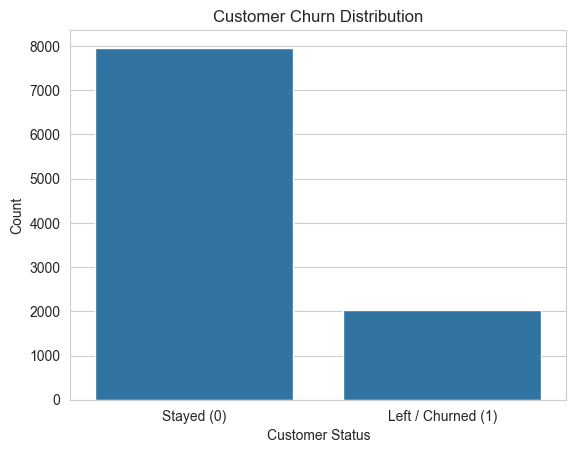

In [ ]:
sns.countplot(
    x="Exited",
    data=df
)

plt.xticks(ticks=[0, 1], labels=["Stayed (0)", "Left / Churned (1)"])

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Count")

plt.show()


### Figure 2.1: Overall Distribution of Customer Churn

### Observation:

The overall churn rate of 20.37% indicates that approximately one in five customers has exited the bank, highlighting a significant customer retention challenge

# 2.2 Geographic Distribution

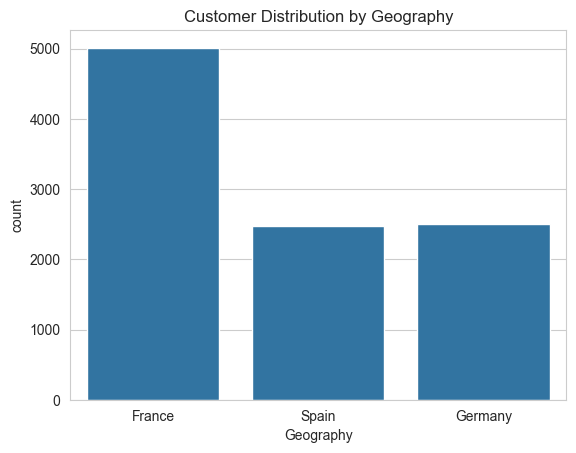

In [ ]:
sns.countplot(
    x="Geography",
    data=df
)

plt.title("Customer Distribution by Geography")
plt.show()

### Figure 2.2: Distribution of Customers Across Countries

### Observation:

France accounts for the largest proportion of the customer portfolio, making it a key market for retention and customer engagement initiatives

## 2.3 Gender Distribution

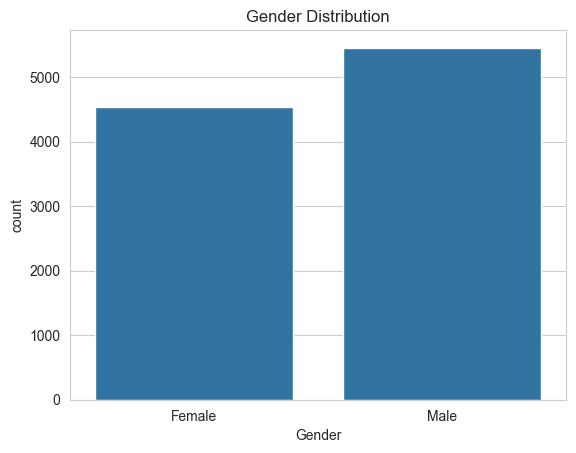

In [ ]:
sns.countplot(
    x="Gender",
    data=df
)

plt.title("Gender Distribution")
plt.show()

### Figure 2.3: Distribution of Customers by Gender

### Observation:

 The customer base is relatively balanced between male and female customers, indicating that the dataset does not exhibit significant gender imbalance

# 2.4 Age Distribution

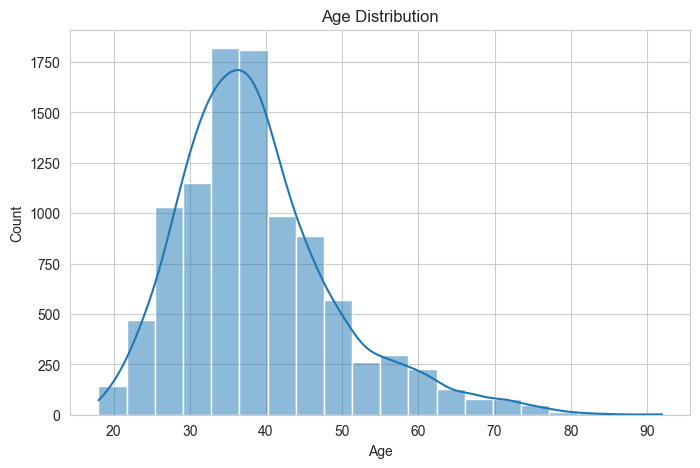

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

### Figure 2.4: Distribution of Customer Age

### Observation:

Most customers are concentrated within the middle-age range, while younger and older customers represent a smaller proportion of the customer base. The distribution suggests that the bank primarily serves working-age individuals.

# 2.5 Balance Distribution

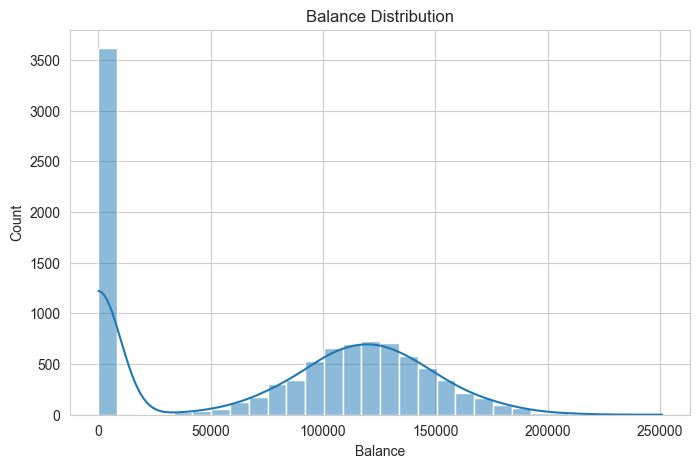

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Balance"],
    bins=30,
    kde=True
)

plt.title("Balance Distribution")
plt.show()

### Figure 2.5: Distribution of Account Balance

### Observation:

More than one-third of customers maintain a zero account balance, indicating the presence of a potentially low-engagement segment that warrants further churn risk assessment.

# 2.6 Active Membership Distribution

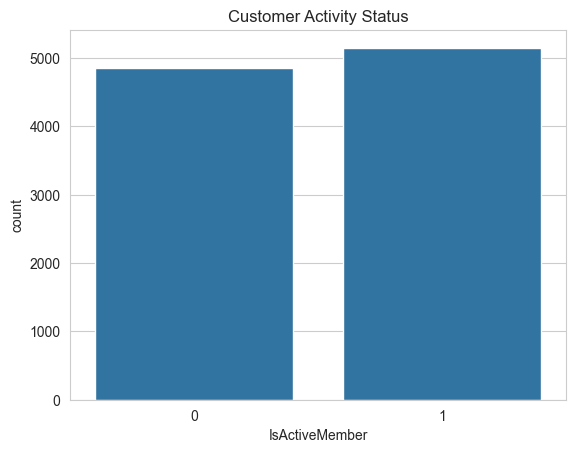

In [ ]:
sns.countplot(
    x="IsActiveMember",
    data=df
)

plt.title("Customer Activity Status")
plt.show()
# 0 = Inactive, 1 = Active

### Figure 2.6: Distribution of Active and Inactive Customers

### Observation:

The dataset contains both active and inactive customers. Customer activity status is an important behavioral indicator and may significantly influence customer churn patterns. This relationship will be explored in subsequent analyses.

# 2.7 Credit Card Ownership Distribution

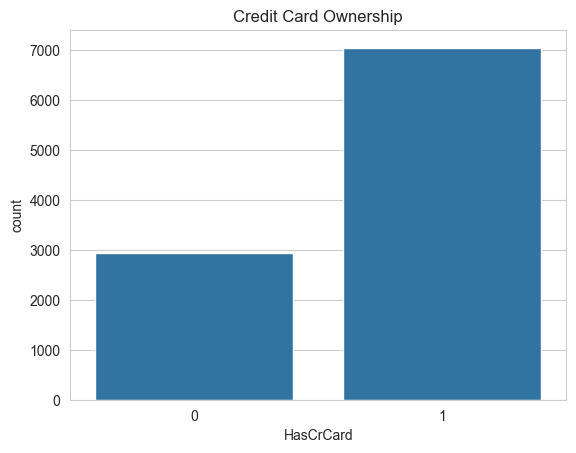

In [ ]:
sns.countplot(
    x="HasCrCard",
    data=df
)

plt.title("Credit Card Ownership")
plt.show()

### Figure 2.7: Distribution of Credit Card Ownership
### Observation:

A majority of customers possess a credit card issued by the bank. Further analysis will determine whether credit card ownership has any significant impact on customer churn behavior.

# 2.8 Tenure Distribution

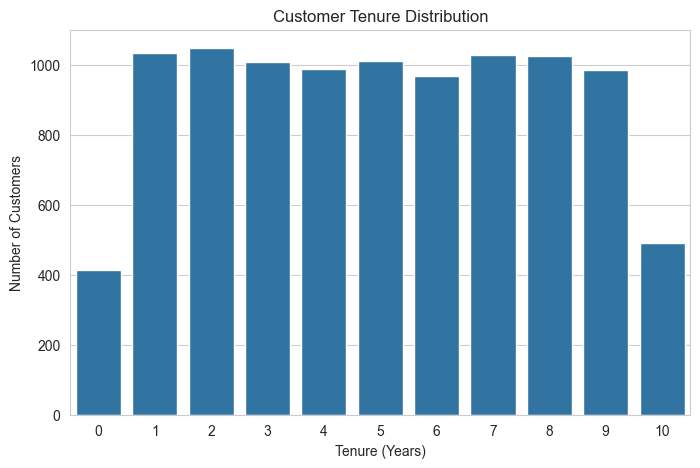

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Tenure"
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Years)")
plt.ylabel("Number of Customers")

plt.show()

### Figure 2.8: Tenure Distribution

### Observation :

1. Customer tenure is relatively evenly distributed between 1 and 9 years, with each tenure group containing a similar number of customers.
2. The 0-year and 10-year tenure groups have noticeably fewer customers than the other categories, indicating that relatively few customers are either newly acquired or have maintained relationships for the maximum recorded tenure.
3. The balanced distribution across most tenure values suggests that the dataset captures customers at various stages of their banking relationship, making it suitable for analyzing how customer loyalty influences churn.

# 2.9: Number of Products Distribution

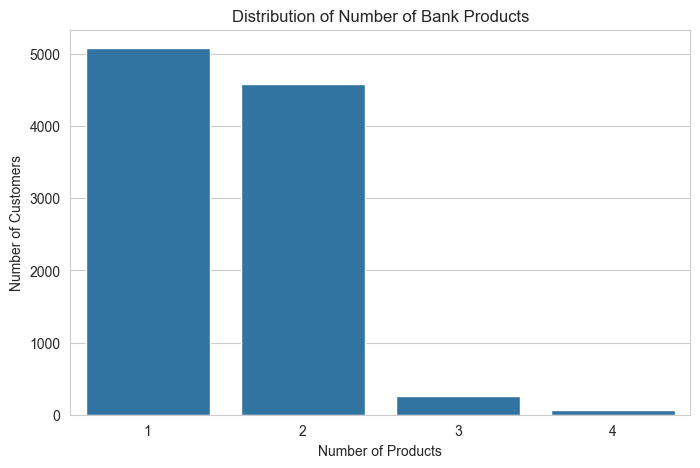

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="NumOfProducts"
)

plt.title("Distribution of Number of Bank Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

plt.show()

### Figure 2.9: Number of Products Distribution

### Observation:

1. Most customers own one or two banking products, with single-product customers representing the largest segment of the customer base.
2. Customers holding three or four products constitute only a small proportion of the overall population, indicating relatively limited adoption of multiple banking services.
3. This distribution suggests that cross-selling opportunities remain available for a significant portion of customers and highlights the importance of investigating whether product ownership influences customer retention in subsequent analyses.

### Key Findings

- The overall customer churn rate is 20.37%.
- France represents the largest customer segment in the dataset.
- The customer base is relatively balanced between male and female customers.
- Most customers belong to the middle-age category.
- Approximately 36.17% of customers maintain a zero account balance.
- The dataset contains both active and inactive customers, making activity status a potentially important factor in churn analysis.
- Credit card ownership is common among customers and will be further investigated during churn-focused analysis.

### Conclusion

The exploratory analysis provided a general understanding of customer demographics, financial characteristics, and engagement patterns. The dataset is now ready for churn-focused analysis to identify high-risk customer segments and potential drivers of customer attrition.